# HIV-Quant: nucleus segmentation and intensity quantification

This notebook walks through the same analysis as `quantify_nuclei_intensity.py`, one step at a time, so you can see what each stage of the pipeline actually does.

**What this pipeline does, in plain terms:**
1. For each microscope image (a `.vsi` file), it looks at the DAPI channel (a stain that lights up cell nuclei) and figures out where each individual nucleus is.
2. For every nucleus it found, it measures how bright the other channels (e.g. HA, CPSF6, Capsid) are inside that nucleus.
3. It combines these per-nucleus measurements across all your images, groups them by experimental condition, and produces summary tables and a plot.

We'll first walk through **one example image** step by step, with pictures at each stage, so you can see (and sanity-check) what's happening. Then we'll run the same steps automatically over every image in your data folder.

This notebook re-uses the actual functions from `quantify_nuclei_intensity.py` (imported below) rather than rewriting them, so the results here match what you'd get running that script directly.

## 1. Setup

Import the libraries and functions we'll use. `quantify_nuclei_intensity` is the pipeline script that lives alongside this notebook — we import its functions directly instead of copy-pasting them.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from bioio import BioImage
from IPython.display import Image
from skimage.color import label2rgb

from quantify_nuclei_intensity import (
    segment_nuclei_3d,
    extract_intensity_metrics,
    process_vsi_file,
    summarize_by_condition,
    plot_intensity_summary,
)

%matplotlib inline

## 2. Configuration

These are the settings you're most likely to need to change for your own experiment. They match the defaults built into `quantify_nuclei_intensity.py`, but you can edit them here.

- `DATA_DIR` — the folder containing your `.vsi` image files.
- `OUTPUT_DIR` — where results (CSVs, plots, label images) will be written.
- `CHANNEL_NAMES` — one name per channel, **in the order they were acquired**. Must include `"DAPI"` somewhere in the list — that's the channel used to find nuclei.
- `NUCLEI_DIAMETER_PX` — roughly how wide (in pixels) a typical nucleus is in your images. Used to filter out blobs that are too small or too large to plausibly be a nucleus.
- `SIZE_TOLERANCE` — how much a detected nucleus's size is allowed to deviate from `NUCLEI_DIAMETER_PX` (as a fraction) and still count. `0.3` means ±30%.
- `CONDITION_MAPPING` — your images' filenames are expected to start with a number, e.g. `10_Multichannel Z-Stack_20260622_67.vsi` starts with `10`. This dictionary maps that leading number to an experimental condition label, so results can be grouped and compared by condition.

If you change `NUCLEI_DIAMETER_PX`, `SIZE_TOLERANCE`, or `CHANNEL_NAMES` later while working through this notebook, just re-run the cells from here downwards.

In [2]:
DATA_DIR = "/nemo/stp/lm/inputs/bishopk/20260715_P32_EXP3_IMAGE_ANALYSIS_CALM/P32_EXP3_COPY1_FOR_DAVE"
OUTPUT_DIR = "./output"

CHANNEL_NAMES = ["DAPI", "HA", "CPSF6", "Capsid"]

NUCLEI_DIAMETER_PX = 140
SIZE_TOLERANCE = 0.3

CONDITION_MAPPING = {
    7: "D37_RR-VLPs", 10: "D37_RR-VLPs", 11: "D37_RR-VLPs", 12: "D37_RR-VLPs", 13: "D37_RR-VLPs",
    14: "D102-VLPs", 15: "D102-VLPs", 16: "D102-VLPs", 22: "D102-VLPs",
    17: "Uninfected", 18: "Uninfected", 19: "Uninfected", 20: "Uninfected", 21: "Uninfected",
}

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Derived from CHANNEL_NAMES above — you shouldn't need to edit these directly.
channels = [(name, idx) for idx, name in enumerate(CHANNEL_NAMES)]
dapi_channel = CHANNEL_NAMES.index("DAPI")

## 3. Find the input files

Before running anything expensive, let's check we can see your `.vsi` files.

In [3]:
vsi_files = sorted(Path(DATA_DIR).glob("*.vsi"))

print(f"Found {len(vsi_files)} .vsi file(s) in {DATA_DIR}:")
for f in vsi_files:
    print(f" - {f.name}")

Found 14 .vsi file(s) in /nemo/stp/lm/inputs/bishopk/20260715_P32_EXP3_IMAGE_ANALYSIS_CALM/P32_EXP3_COPY1_FOR_DAVE:
 - 10_Multichannel Z-Stack_20260622_67.vsi
 - 11_Multichannel Z-Stack_20260622_68.vsi
 - 12_Multichannel Z-Stack_20260622_69.vsi
 - 13_Multichannel Z-Stack_20260622_70.vsi
 - 14_Multichannel Z-Stack_20260622_71.vsi
 - 15_Multichannel Z-Stack_20260622_72.vsi
 - 16_Multichannel Z-Stack_20260622_73.vsi
 - 17_Multichannel Z-Stack_20260622_74.vsi
 - 18_Multichannel Z-Stack_20260625_76.vsi
 - 19_Multichannel Z-Stack_20260625_77.vsi
 - 20_Multichannel Z-Stack_20260625_78.vsi
 - 21_Multichannel Z-Stack_20260625_80.vsi
 - 22_Multichannel Z-Stack_20260625_82.vsi
 - 7_Multichannel Z-Stack_20260622_64.vsi


## 4. Walkthrough: processing one image step by step

Before processing every image, let's run through the pipeline on a single example file so you can see what's happening — and check it looks sensible — before trusting it on the rest of your data.

We'll just use the first file found.

### 4a. Load the image

`BioImage` reads the `.vsi` file. The resulting array has 4 dimensions, in the order **(channel, z, y, x)**:
- **channel** — which fluorescent stain (DAPI, HA, etc.)
- **z** — depth through the 3D image stack
- **y, x** — the 2D position within each slice

In [4]:
example_file = vsi_files[0]
print(f"Using example file: {example_file.name}")

bio_image = BioImage(example_file)
image_data = bio_image.get_image_data("CZYX", T=0)

print(f"Image shape (channels, z, y, x): {image_data.shape}")

dapi_stack = image_data[dapi_channel]
mid_z = dapi_stack.shape[0] // 2

Using example file: 10_Multichannel Z-Stack_20260622_67.vsi
Image shape (channels, z, y, x): (4, 9, 2304, 2304)


### 4b. Look at the raw DAPI signal

This is the raw, unprocessed data the segmentation step below will work from — a single slice (`mid_z`) from the middle of the DAPI z-stack.

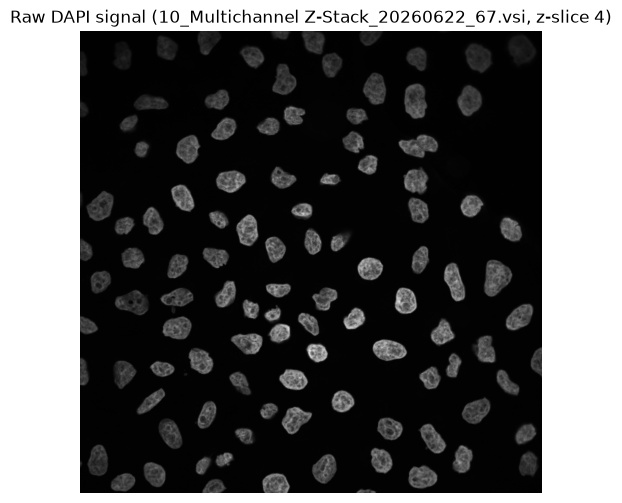

In [5]:
plt.figure(figsize=(6, 6))
plt.imshow(dapi_stack[mid_z], cmap="gray")
plt.title(f"Raw DAPI signal ({example_file.name}, z-slice {mid_z})")
plt.axis("off")
plt.show()

### 4c. Segment nuclei

`segment_nuclei_3d` smooths the image to reduce noise, separates bright (nucleus) from dark (background) regions, cleans up the result, and keeps only the blobs whose size is consistent with `NUCLEI_DIAMETER_PX`/`SIZE_TOLERANCE`. Each surviving blob gets its own ID number — that's a detected nucleus.

In [6]:
labeled_nuclei = segment_nuclei_3d(dapi_stack, NUCLEI_DIAMETER_PX, SIZE_TOLERANCE)
num_nuclei = int(labeled_nuclei.max())

print(f"Detected {num_nuclei} nuclei in {example_file.name}")

/nemo/stp/lm/working/barryd/hpc/projects/labs/bishop/mariana/hiv-quant/quantify_nuclei_intensity.py:76: FutureWarning: `binary_erosion` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.erosion` instead. Note the pixel shift by 1 for even-sized footprints (see docstring notes).
  binary_mask = morphology.binary_erosion(binary_mask, morphology.ball(2))
/nemo/stp/lm/working/barryd/hpc/projects/labs/bishop/mariana/hiv-quant/quantify_nuclei_intensity.py:77: FutureWarning: `binary_dilation` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.dilation` instead. Note the lack of mirroring for non-symmetric footprints (see docstring notes).
  binary_mask = morphology.binary_dilation(binary_mask, morphology.ball(2))


Detected 112 nuclei in 10_Multichannel Z-Stack_20260622_67.vsi


### 4d. Check the segmentation visually

This overlays the detected nuclei (in colour) on top of the raw DAPI signal, for the same slice as above. **This is the most important sanity check in this notebook** — if the coloured blobs don't line up with the nuclei you can see by eye, or if there are obviously too many/too few, go back to the Configuration cell, adjust `NUCLEI_DIAMETER_PX`/`SIZE_TOLERANCE`, and re-run from there.

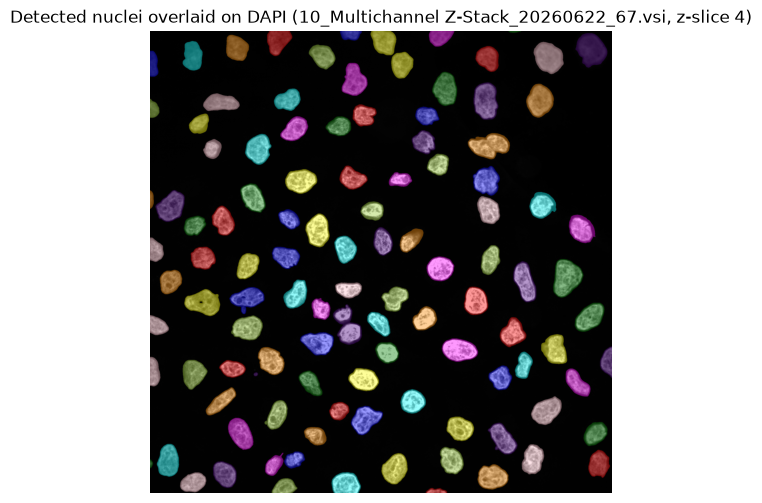

In [7]:
dapi_min, dapi_max = np.percentile(dapi_stack, [1, 99])
dapi_normalized = np.clip((dapi_stack[mid_z] - dapi_min) / (dapi_max - dapi_min), 0, 1)
overlay = label2rgb(labeled_nuclei[mid_z], image=dapi_normalized, bg_label=0, alpha=0.4)

plt.figure(figsize=(6, 6))
plt.imshow(overlay)
plt.title(f"Detected nuclei overlaid on DAPI ({example_file.name}, z-slice {mid_z})")
plt.axis("off")
plt.show()

### 4e. Measure intensity in each nucleus

For every detected nucleus and every channel (including DAPI itself), `extract_intensity_metrics` computes the mean, median, min, max, standard deviation, and total intensity across all the voxels (3D pixels) belonging to that nucleus.

In [8]:
example_metrics = extract_intensity_metrics(
    image_data, labeled_nuclei, np.arange(1, num_nuclei + 1), channels
)
example_metrics.head()

,nucleus_id,DAPI_mean,DAPI_median,DAPI_min,DAPI_max,DAPI_std,DAPI_total,HA_mean,HA_median,HA_min,...,CPSF6_min,CPSF6_max,CPSF6_std,CPSF6_total,Capsid_mean,Capsid_median,Capsid_min,Capsid_max,Capsid_std,Capsid_total
0,1,867.354793,715.0,109,3657,558.625458,86668693.0,655.770383,583.0,150,...,92,4918,416.978764,66847624.0,778.646138,693.0,143,8243,404.376002,77804658.0
1,2,1085.175217,779.0,122,3785,794.256909,39705476.0,760.158928,657.0,170,...,111,5369,527.761349,30569310.0,695.700292,623.0,178,2942,317.439093,25454978.0
2,3,1188.873615,908.0,116,5028,832.613340,131469211.0,653.343959,576.0,134,...,82,6638,645.388327,105409841.0,617.798776,554.0,135,4580,295.914458,68318042.0
3,4,899.975924,709.0,110,3228,595.239165,58463336.0,477.677791,425.0,145,...,135,6982,786.606739,75818001.0,523.983990,450.0,131,9949,329.740726,34038524.0
4,5,503.646221,339.0,125,1772,371.145791,1625770.0,526.790582,334.0,137,...,102,3293,410.088953,2283621.0,830.155824,511.0,228,12826,1342.544111,2679743.0


## 5. Process every image

Now that we've seen what happens for one file, let's run the same steps — segmentation, label-image export, and intensity measurement — over every `.vsi` file in `DATA_DIR`, using `process_vsi_file` (the same function the command-line version of this pipeline uses). This may take a while depending on how many files you have.

For each file, a folder of PNG images showing the segmentation (like the overlay above, but for every z-slice) is saved under `output/label_images/<filename>/` — useful for double-checking segmentation quality across your whole dataset, not just the one example above.

In [9]:
all_measurements = []

for vsi_file in vsi_files:
    df = process_vsi_file(
        str(vsi_file), dapi_channel, channels, NUCLEI_DIAMETER_PX, SIZE_TOLERANCE, CONDITION_MAPPING
    )
    if df is not None and len(df) > 0:
        all_measurements.append(df)

print(f"\nSuccessfully processed {len(all_measurements)} of {len(vsi_files)} file(s)")

Processing: /nemo/stp/lm/inputs/bishopk/20260715_P32_EXP3_IMAGE_ANALYSIS_CALM/P32_EXP3_COPY1_FOR_DAVE/10_Multichannel Z-Stack_20260622_67.vsi


/nemo/stp/lm/working/barryd/hpc/projects/labs/bishop/mariana/hiv-quant/quantify_nuclei_intensity.py:76: FutureWarning: `binary_erosion` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.erosion` instead. Note the pixel shift by 1 for even-sized footprints (see docstring notes).
  binary_mask = morphology.binary_erosion(binary_mask, morphology.ball(2))
/nemo/stp/lm/working/barryd/hpc/projects/labs/bishop/mariana/hiv-quant/quantify_nuclei_intensity.py:77: FutureWarning: `binary_dilation` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.dilation` instead. Note the lack of mirroring for non-symmetric footprints (see docstring notes).
  binary_mask = morphology.binary_dilation(binary_mask, morphology.ball(2))


  Found 112 nuclei
Processing: /nemo/stp/lm/inputs/bishopk/20260715_P32_EXP3_IMAGE_ANALYSIS_CALM/P32_EXP3_COPY1_FOR_DAVE/11_Multichannel Z-Stack_20260622_68.vsi
  Found 94 nuclei
Processing: /nemo/stp/lm/inputs/bishopk/20260715_P32_EXP3_IMAGE_ANALYSIS_CALM/P32_EXP3_COPY1_FOR_DAVE/12_Multichannel Z-Stack_20260622_69.vsi
  Found 66 nuclei
Processing: /nemo/stp/lm/inputs/bishopk/20260715_P32_EXP3_IMAGE_ANALYSIS_CALM/P32_EXP3_COPY1_FOR_DAVE/13_Multichannel Z-Stack_20260622_70.vsi
  Found 48 nuclei
Processing: /nemo/stp/lm/inputs/bishopk/20260715_P32_EXP3_IMAGE_ANALYSIS_CALM/P32_EXP3_COPY1_FOR_DAVE/14_Multichannel Z-Stack_20260622_71.vsi
  Found 132 nuclei
Processing: /nemo/stp/lm/inputs/bishopk/20260715_P32_EXP3_IMAGE_ANALYSIS_CALM/P32_EXP3_COPY1_FOR_DAVE/15_Multichannel Z-Stack_20260622_72.vsi
  Found 128 nuclei
Processing: /nemo/stp/lm/inputs/bishopk/20260715_P32_EXP3_IMAGE_ANALYSIS_CALM/P32_EXP3_COPY1_FOR_DAVE/16_Multichannel Z-Stack_20260622_73.vsi
  Found 56 nuclei
Processing: /nemo/s

## 6. Save and preview the full results

Combine the per-file results into one table, with one row per nucleus, and save it as a CSV you can open in Excel or re-load elsewhere.

In [10]:
results_df = pd.concat(all_measurements, ignore_index=True)

measurements_file = os.path.join(OUTPUT_DIR, "nuclei_measurements.csv")
results_df.to_csv(measurements_file, index=False)

print(f"Saved {len(results_df)} nucleus measurements to {measurements_file}")
results_df.head()

Saved 1490 nucleus measurements to ./output/nuclei_measurements.csv


,nucleus_id,DAPI_mean,DAPI_median,DAPI_min,DAPI_max,DAPI_std,DAPI_total,HA_mean,HA_median,HA_min,...,CPSF6_std,CPSF6_total,Capsid_mean,Capsid_median,Capsid_min,Capsid_max,Capsid_std,Capsid_total,filename,condition
0,1,867.354793,715.0,109,3657,558.625458,86668693.0,655.770383,583.0,150,...,416.978764,66847624.0,778.646138,693.0,143,8243,404.376002,77804658.0,10_Multichannel Z-Stack_20260622_67.vsi,D37_RR-VLPs
1,2,1085.175217,779.0,122,3785,794.256909,39705476.0,760.158928,657.0,170,...,527.761349,30569310.0,695.700292,623.0,178,2942,317.439093,25454978.0,10_Multichannel Z-Stack_20260622_67.vsi,D37_RR-VLPs
2,3,1188.873615,908.0,116,5028,832.613340,131469211.0,653.343959,576.0,134,...,645.388327,105409841.0,617.798776,554.0,135,4580,295.914458,68318042.0,10_Multichannel Z-Stack_20260622_67.vsi,D37_RR-VLPs
3,4,899.975924,709.0,110,3228,595.239165,58463336.0,477.677791,425.0,145,...,786.606739,75818001.0,523.983990,450.0,131,9949,329.740726,34038524.0,10_Multichannel Z-Stack_20260622_67.vsi,D37_RR-VLPs
4,5,503.646221,339.0,125,1772,371.145791,1625770.0,526.790582,334.0,137,...,410.088953,2283621.0,830.155824,511.0,228,12826,1342.544111,2679743.0,10_Multichannel Z-Stack_20260622_67.vsi,D37_RR-VLPs


## 7. Summarize by condition

Average the per-nucleus measurements within each experimental condition (as assigned via `CONDITION_MAPPING`), giving one row per condition.

In [11]:
summary_df = summarize_by_condition(results_df)

summary_file = os.path.join(OUTPUT_DIR, "summary_statistics.csv")
summary_df.to_csv(summary_file, index=False)

print(f"Saved summary statistics to {summary_file}")
summary_df[["condition", "num_images", "num_nuclei"]]

Saved summary statistics to ./output/summary_statistics.csv


,condition,num_images,num_nuclei
0,D37_RR-VLPs,5,390
1,D102-VLPs,4,436
2,Uninfected,5,664


## 8. Summary plot

For each channel, this plots the per-nucleus mean intensity (normalized to that nucleus's own DAPI signal, on a log scale), grouped by condition, as a boxplot with the individual nuclei shown as dots on top.

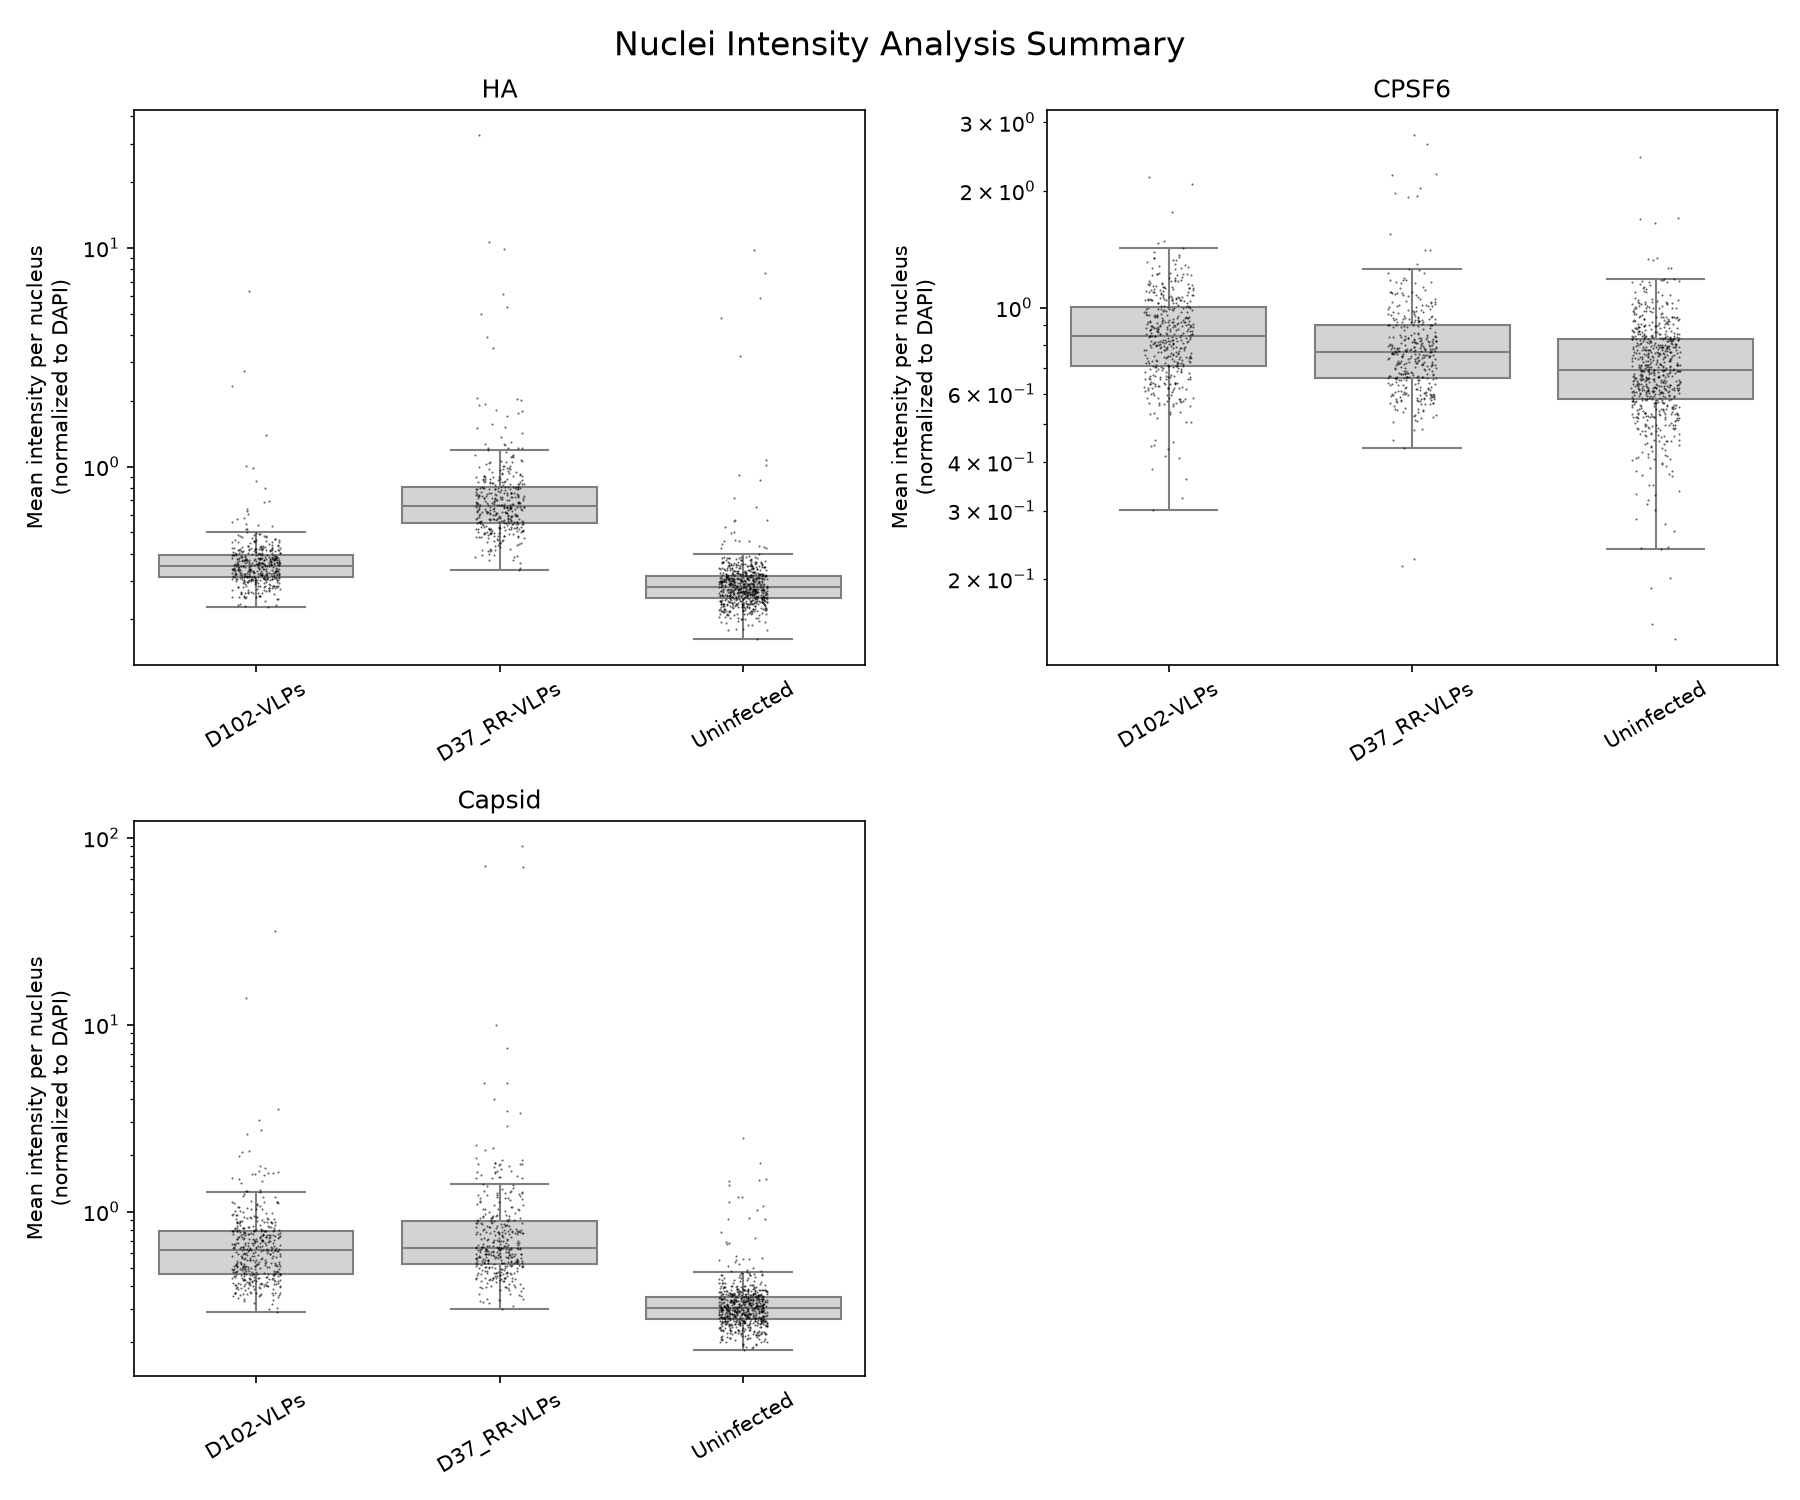

In [12]:
plot_file = os.path.join(OUTPUT_DIR, "intensity_summary.png")
plot_intensity_summary(results_df, plot_file, channels)

Image(filename=plot_file)

## Done

Everything produced by this notebook is in `./output/` (or wherever you set `OUTPUT_DIR` above):

- `nuclei_measurements.csv` — one row per nucleus, with intensity metrics for every channel
- `summary_statistics.csv` — mean/std of each metric, one row per condition
- `intensity_summary.png` — the plot shown above
- `label_images/<filename>/z###.png` — per-slice segmentation overlays for every input file, for visually checking segmentation quality

If the results don't look right, the most likely thing to revisit is the segmentation quality check in step 4d — adjust `NUCLEI_DIAMETER_PX`/`SIZE_TOLERANCE` in the Configuration cell and re-run the notebook from there.